# 02 · Crop action-feature research

**Status: first bounded experiment; feature research remains open.**

We test crop lifecycle value, watering urgency, labor allocation and terminal banking in one fixed deterministic scheduler. Each comparison removes one family’s contribution. The result is conditional on this policy and its fixed weights, not a universal ranking of features.

[Experiment specification](../docs/feature_experiment.md) · [Official mechanics](https://github.com/Kaggle/kaggle-environments/tree/master/kaggle_environments/envs/kaggriculture) · [Companion discussion](https://www.kaggle.com/competitions/kaggriculture/discussion/740550)

The scope is 80 full games: five variants, two deterministic opponents, four development seeds and both seats. No validation or holdout seeds, fitted coefficients, final model selection or competition submission.

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from kaggriculture_research.artifacts import digest, file_digest
from kaggriculture_research.crop_policy import crop_scenario
from kaggriculture_research.environment import game
from kaggriculture_research.visuals import show_figure

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
report = json.loads((root / "reports/feature_research.json").read_text())
protocol = json.loads((root / "configs/feature_research.json").read_text())
assert digest(protocol) == report["protocol_sha256"]
for name, sha in report["lineage"]["code"].items():
    assert file_digest(root / "src/kaggriculture_research" / name) == sha, name
assert report["games"] == 80 and not report["validation_or_holdout_used"]
assert report["feature_completion_gate"] == "closed"
print(
    "Verified:", report["games"], "full games; four development seed clusters; feature gate closed."
)

Verified: 80 full games; four development seed clusters; feature gate closed.


## Mechanism before measurement

A crop’s advertised maximum yield is not its guaranteed yield. We simulate daily irrigation without fertilizer and compare the formula with the official interpreter in tests. The conditional value uses current market prices and seed cost. It assumes one harvest and two delivery actions; it does not predict future prices, actual route feasibility or the opponent’s sales. The scheduler separately checks end-of-season delivery distance.

For non-repeating crops, watering on the harvest day can add yield. A newly planted crop begins with one unwatered day. The final partial day has no automatic deposit before scoring: carried produce must reach the shed and be sold.

In [2]:
scenario_rows = []
for crop in sorted(game.CROPS):
    scenario = crop_scenario(crop, 10000, 719, 0)
    scenario_rows.append(
        {
            "crop": crop,
            "advertised_cap": game.CROPS[crop]["max_yield"],
            "irrigated_units": scenario.units,
            "harvest_age_days": scenario.harvest_age,
            "work_actions": scenario.work_actions,
            "conditional_net_coins": scenario.net_coins,
            "net_coins_per_work_action": round(scenario.net_coins / scenario.work_actions, 2),
        }
    )
scenarios = pd.DataFrame(scenario_rows)
display(scenarios)

,crop,advertised_cap,irrigated_units,harvest_age_days,work_actions,conditional_net_coins,net_coins_per_work_action
0,CARROT,4,3,3,8,82.0,10.25
1,MELON,6,6,12,17,1420.0,83.53
2,STRAWBERRY,4,4,16,21,368.0,17.52
3,TOMATO,4,4,11,16,179.0,11.19
4,WHEAT,6,4,4,9,87.0,9.67


## Feature ledger and intervention

These are 13 action-feature templates instantiated per crop, tile or task. They are separate from notebook 01’s 244 state descriptors. They have been screened through mechanics, information-availability checks and grouped ablations; none is finally retained or rejected yet. An unhelpful result under one scheduler is insufficient evidence to discard a family.

| Family | Fixed intervention when removed | Availability |
|---|---|---|
| Crop value | Equal planting scores instead of conditional net value per work action | Public crop mechanics, current market and own seeds |
| Water urgency | Fixed watering priority instead of mortality, bonus and refresh-slack terms | Public crop state and current clock |
| Labor | Remove distance weighting and workload-based hiring | Own positions, public tasks, clock and hire cost |
| Terminal | Remove maturity/banking limits and final-day carry priority | Remaining official decisions, own inventory and delivery distance |

All variants retain the same action generator, legal-action filter, reservation logic, deterministic tie-breaking and immediate shed-sales rule. No hidden replay fields enter the policy.

In [3]:
display(
    pd.DataFrame(
        [
            {
                "family": family,
                "templates": len(names),
                "features": ", ".join(names),
                "status": "provisional; family ablation evaluated",
            }
            for family, names in report["feature_templates"].items()
        ]
    )
)
print(
    {
        k: report[k]
        for k in (
            "generated_templates",
            "screened_templates",
            "retained_templates",
            "rejected_templates",
            "provisional_templates",
        )
    }
)

,family,templates,features,status
0,crop_value,3,"conditional_units, conditional_net_coins, net_...",provisional; family ablation evaluated
1,labor,4,"travel_actions, workload_actions, worker_capac...",provisional; family ablation evaluated
2,terminal,3,"decision_slack, can_bank_crop, last_day_carry_...",provisional; family ablation evaluated
3,water_urgency,3,"dies_next_refresh, water_bonus_units, refresh_...",provisional; family ablation evaluated


{'generated_templates': 13, 'screened_templates': 13, 'retained_templates': 0, 'rejected_templates': 0, 'provisional_templates': 13}


## Outcomes across the two development opponents

The official starter is a narrow reference. The carrot scheduler waters, harvests, clears weeds and sells using the same framework restricted to carrots and one farmer. These give different market activity, but neither represents leaderboard-strength opposition. A saturated local win rate makes cash diagnostics informative without turning them into the official metric.

,games,ineffective_farm_actions,match_score,mean_coin_margin,mean_coins,mean_unsold_units,opponent,variant
0,8,0,1.000,26839.375,35287.500,0.000,carrot_scheduler,full
1,8,0,1.000,30201.125,33881.750,0.000,starter,full
2,8,0,1.000,4187.000,8874.000,0.000,carrot_scheduler,no_crop_value
3,8,0,1.000,9989.625,13379.875,0.000,starter,no_crop_value
4,8,0,0.625,380.625,6778.875,0.000,carrot_scheduler,no_labor
5,8,0,0.875,3763.000,7392.125,0.000,starter,no_labor
6,8,0,1.000,22014.125,30524.500,1.875,carrot_scheduler,no_terminal
7,8,0,1.000,25112.125,28792.750,0.000,starter,no_terminal
8,8,0,1.000,26782.500,34652.500,0.000,carrot_scheduler,no_water_urgency
9,8,0,1.000,29351.750,33032.375,0.000,starter,no_water_urgency


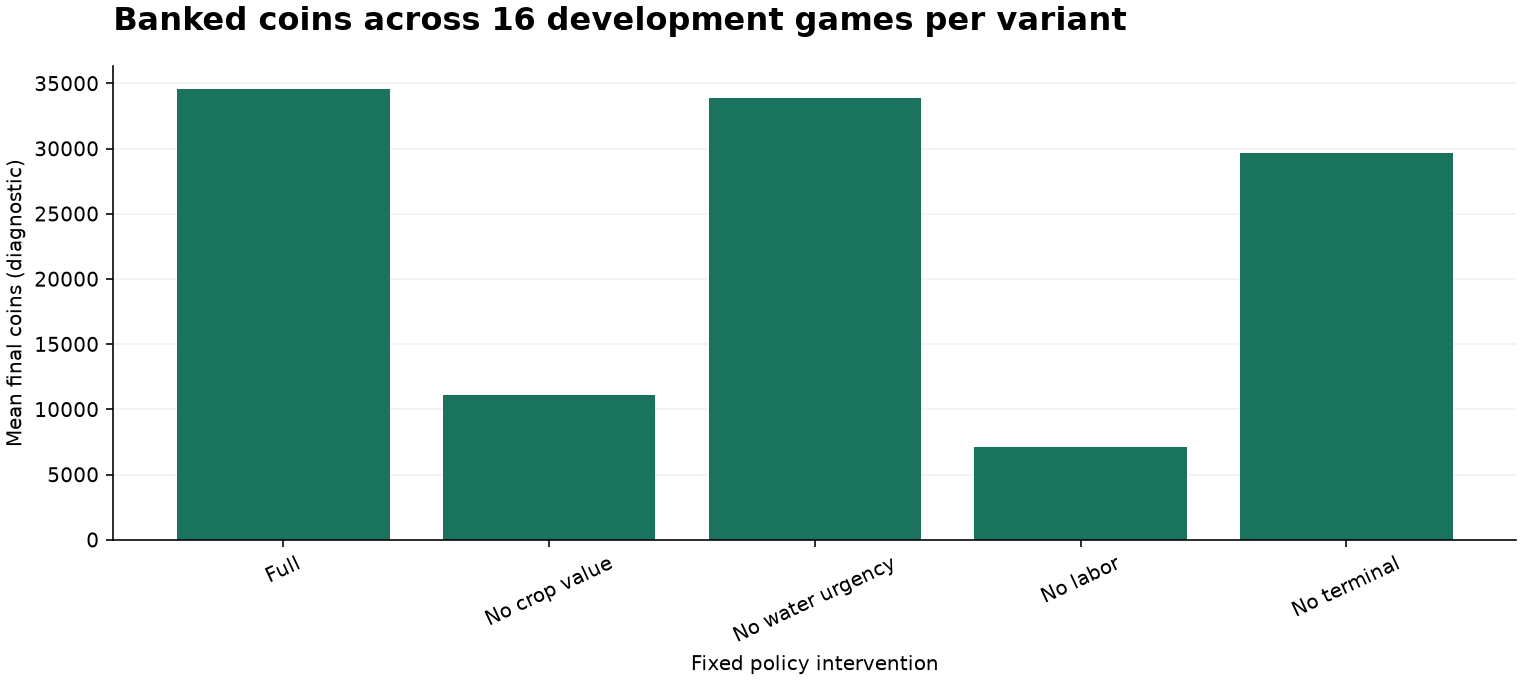

In [4]:
games = pd.read_csv(root / "reports/feature_games.csv")
pairs = pd.read_csv(root / "reports/feature_ablations.csv")
display(pd.DataFrame(report["group_results"]).round(3))
labels = {
    "full": "Full",
    "no_crop_value": "No crop value",
    "no_water_urgency": "No water urgency",
    "no_labor": "No labor",
    "no_terminal": "No terminal",
}
order = list(labels)
means = games.groupby("variant").coins.mean().reindex(order)
fig = go.Figure(go.Bar(x=[labels[v] for v in order], y=means.to_list()))
fig.update_layout(
    title="Banked coins across 16 development games per variant",
    xaxis_title="Fixed policy intervention",
    yaxis_title="Mean final coins (diagnostic)",
)
show_figure(fig)

## Paired family effects and uncertainty

We subtract each ablated policy’s outcome from the full policy for the same seed, seat and opponent, then average within seed. Bootstrap resampling operates on **four whole seed clusters**, preserving both seats and both opponents. The 95% percentile intervals are descriptive; this small exploratory batch supports no strong significance claim or multiple-comparison conclusion.

Positive coin or match-score differences favor the full policy. Negative unsold-inventory differences favor the full policy. Equal initial seeds do not force identical future towns: farm changes can alter consumption of the environment’s shared random stream.

,ablation,metric,full_minus_ablated,bootstrap_low,bootstrap_high,seed_clusters
0,no_crop_value,match_score,0.000,0.000,0.000,4
1,no_crop_value,coin_margin,21431.938,19746.812,22692.125,4
2,no_crop_value,coins,23457.688,20968.938,26012.000,4
3,no_crop_value,unsold_product_units,0.000,0.000,0.000,4
4,no_water_urgency,match_score,0.000,0.000,0.000,4
5,no_water_urgency,coin_margin,453.125,-791.938,1788.812,4
6,no_water_urgency,coins,742.188,-789.125,2653.188,4
7,no_water_urgency,unsold_product_units,0.000,0.000,0.000,4
8,no_labor,match_score,0.250,0.000,0.562,4
9,no_labor,coin_margin,26448.438,24238.250,29296.562,4


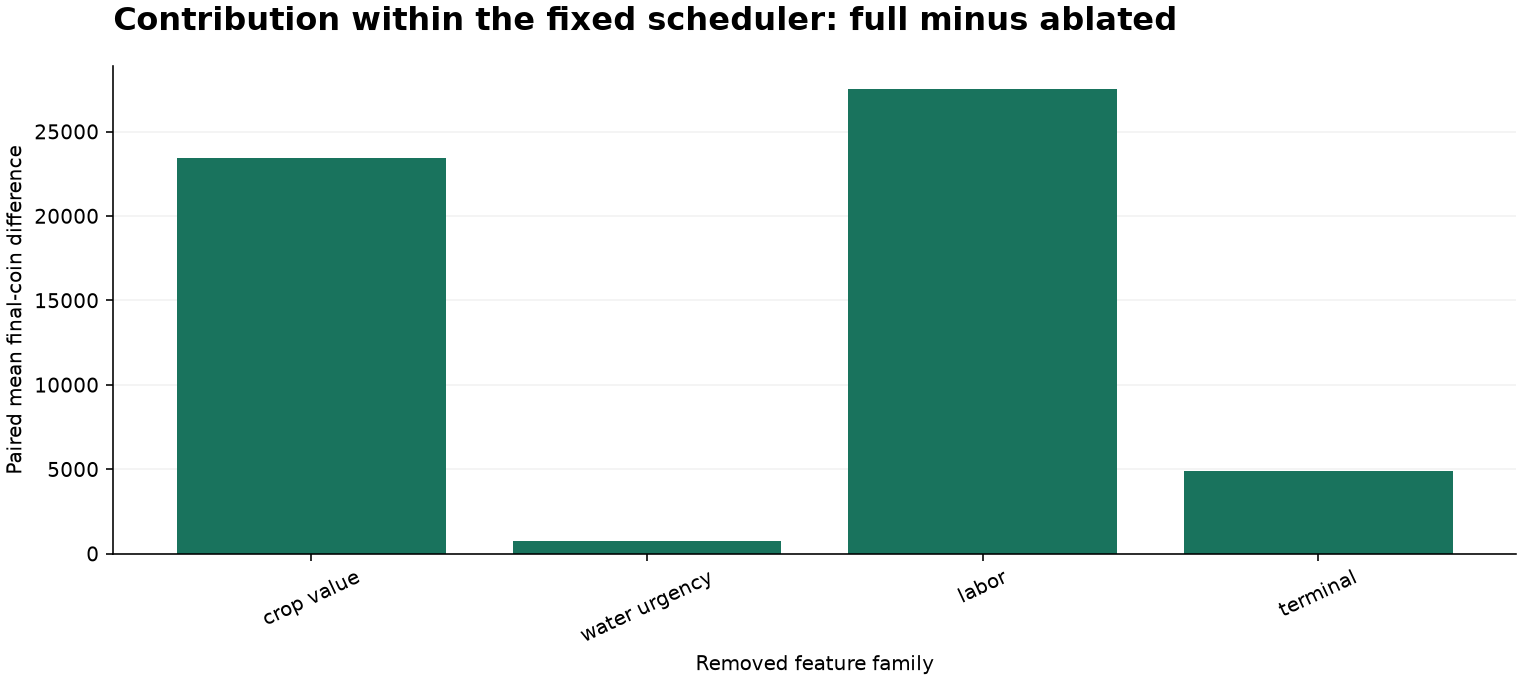

In [5]:
display(
    pairs[
        [
            "ablation",
            "metric",
            "full_minus_ablated",
            "bootstrap_low",
            "bootstrap_high",
            "seed_clusters",
        ]
    ].round(3)
)
effects = pairs[pairs.metric == "coins"]
fig = go.Figure(
    go.Bar(
        x=[labels[v].removeprefix("No ") for v in effects.ablation],
        y=effects.full_minus_ablated.to_list(),
    )
)
fig.update_layout(
    title="Contribution within the fixed scheduler: full minus ablated",
    xaxis_title="Removed feature family",
    yaxis_title="Paired mean final-coin difference",
)
show_figure(fig)

## Study the behavior, not just the score

Planting mix helps distinguish crop-choice effects from labor throughput. Harvest, water and inventory diagnostics expose failed schedules. The ineffective-action counter applies the official own-farm action function to a copy of legal observations; it measures farm actions with no effect, not market-order failures. Latency is measured in local Python callbacks and is not a competition-sandbox performance guarantee.

In [6]:
behavior = [
    "plants",
    "harvests",
    "waters",
    "passes",
    "unsold_product_units",
    "ineffective_farm_actions",
]
display(games.groupby("variant")[behavior].mean().reindex(order).round(2))
crop_columns = ["plant_" + crop for crop in sorted(game.CROPS)]
display(games.groupby("variant")[crop_columns].sum().reindex(order))
display(pd.DataFrame(report["latency_ms"]).T.round(3).rename_axis("variant"))
assert games.ineffective_farm_actions.sum() == 0
print("Silent ineffective farm actions:", int(games.ineffective_farm_actions.sum()))

,plants,harvests,waters,passes,unsold_product_units,ineffective_farm_actions
variant,,,,,,
full,74.81,66.06,688.12,108.56,0.00,0.0
no_crop_value,155.06,141.38,601.75,29.69,0.00,0.0
no_water_urgency,81.12,61.88,647.38,67.88,0.00,0.0
no_labor,26.69,4.69,183.12,15.75,0.00,0.0
no_terminal,76.56,50.44,726.81,114.81,0.94,0.0


,plant_CARROT,plant_MELON,plant_STRAWBERRY,plant_TOMATO,plant_WHEAT
variant,,,,,
full,224,800,0,0,173
no_crop_value,2475,0,0,0,6
no_water_urgency,198,880,64,0,156
no_labor,7,409,0,0,11
no_terminal,51,992,182,0,0


,max,median,p95
variant,,,
full,165.179,2.149,2.606
no_crop_value,137.979,1.956,2.485
no_labor,89.868,0.970,1.103
no_terminal,141.621,2.167,2.720
no_water_urgency,150.011,2.097,2.565


Silent ineffective farm actions: 0


## Evidence ledger and next boundary

Every raw episode is stored privately with its exact legal callback observations, actions, feature diagnostics, source lineage and semantic checksum. Public summaries are small enough to review. The following check validates all saved episode files without launching another experiment.

In [7]:
for artifact in report["artifact_manifest"]:
    assert file_digest(root / artifact["path"]) == artifact["sha256"], artifact["path"]
print("Verified", len(report["artifact_manifest"]), "private episode artifacts against the report.")
for limitation in report["limitations"]:
    print("•", limitation)

Verified 80 private episode artifacts against the report.
• Four development seed clusters only
• Two limited deterministic opponents
• Policy-component effects depend on the fixed scheduler and weights
• Current-price irrigated scenarios are not future market forecasts
• Shared environmental RNG may diverge when policies change farm state
• No final model selection, competitive claim, or leaderboard submission


**Research decision:** keep all four families provisional. This experiment establishes a measurable first layer; it does not close feature engineering. Next investigate market pressure and visible town demand, storage constraints, fertilizer and livestock economics, longer planning horizons and stronger development opponents. Validation follows only after the broader feature specification is frozen. The completion gate remains closed.